In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
songs_df_raw = pd.read_csv('../app/data/dataset.csv')

In [3]:
songs_df_raw.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
songs_df_raw.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
songs_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
songs_df_raw.isna().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
songs_df_raw[songs_df_raw["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [8]:
songs_df_clean = songs_df_raw.dropna(subset=["artists"])

In [9]:
songs_df_clean = songs_df_clean.drop(columns=["Unnamed: 0"])

In [10]:
songs_df_clean

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


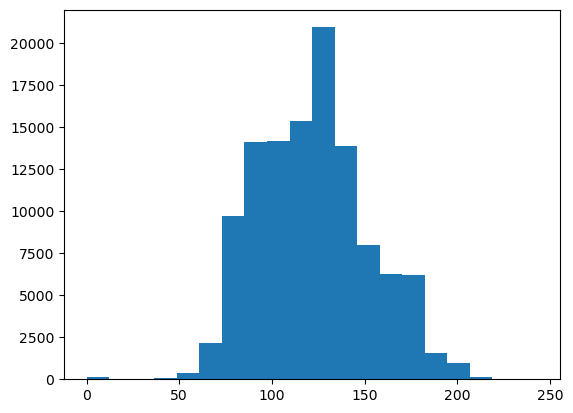

In [11]:
plt.hist(songs_df_clean["tempo"], bins=20)
plt.show()

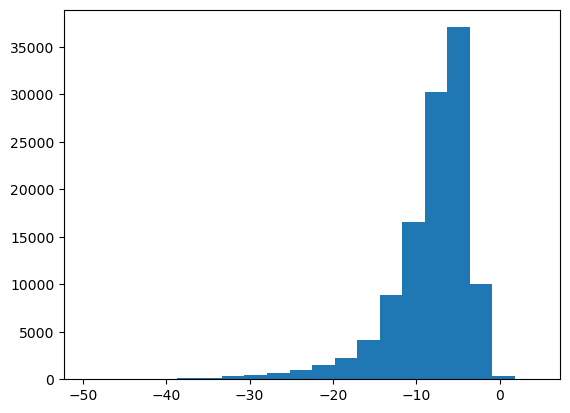

In [12]:
plt.hist(songs_df_clean["loudness"], bins=20)
plt.show()

In [13]:
features_df = songs_df_clean[["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]]

Used StandardScaler to scale the features to have mean 0 and standard deviation 1

In [14]:
scaler = StandardScaler()

features_scaled = scaler.fit_transform(features_df)

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_df.columns,
    index=songs_df_clean.index 
)

final_df = pd.concat(
    [songs_df_clean[["track_name", "artists"]], 
    features_scaled_df],
    axis=1
)

In [15]:
features_scaled_df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.629239,-0.717147,0.300825,0.551843,-0.850193,-0.504111,0.758735,0.929315,-1.141854
1,-0.845908,-1.889974,-1.784739,-0.078995,1.831744,-0.504097,-0.591216,-0.798681,-1.489708
2,-0.742187,-1.122667,-0.293289,-0.273827,-0.315489,-0.504115,-0.507172,-1.365679,-1.528303
3,-1.733301,-2.312987,-2.039246,-0.457309,1.774605,-0.503886,-0.428381,-1.276965,1.987857
4,0.295026,-0.788709,-0.282751,-0.303146,0.463409,-0.504115,-0.686290,-1.184394,-0.073343
...,...,...,...,...,...,...,...,...,...
113995,-2.274956,-1.615652,-1.617321,-0.401507,0.977663,2.493742,-0.668431,-1.697779,0.128337
113996,-2.263432,-2.084782,-2.000075,-0.421369,2.042258,2.648803,-0.570205,-1.693536,-1.231186
113997,0.358411,-1.241937,-0.524135,-0.403399,1.660327,-0.504115,-0.681038,1.037314,0.341259
113998,0.116395,-0.538241,-0.522942,-0.519731,0.198764,-0.504115,0.296495,-0.235539,0.460746


In [16]:
final_df

,track_name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Comedy,Gen Hoshino,0.629239,-0.717147,0.300825,0.551843,-0.850193,-0.504111,0.758735,0.929315,-1.141854
1,Ghost - Acoustic,Ben Woodward,-0.845908,-1.889974,-1.784739,-0.078995,1.831744,-0.504097,-0.591216,-0.798681,-1.489708
2,To Begin Again,Ingrid Michaelson;ZAYN,-0.742187,-1.122667,-0.293289,-0.273827,-0.315489,-0.504115,-0.507172,-1.365679,-1.528303
3,Can't Help Falling In Love,Kina Grannis,-1.733301,-2.312987,-2.039246,-0.457309,1.774605,-0.503886,-0.428381,-1.276965,1.987857
4,Hold On,Chord Overstreet,0.295026,-0.788709,-0.282751,-0.303146,0.463409,-0.504115,-0.686290,-1.184394,-0.073343
...,...,...,...,...,...,...,...,...,...,...,...
113995,Sleep My Little Boy,Rainy Lullaby,-2.274956,-1.615652,-1.617321,-0.401507,0.977663,2.493742,-0.668431,-1.697779,0.128337
113996,Water Into Light,Rainy Lullaby,-2.263432,-2.084782,-2.000075,-0.421369,2.042258,2.648803,-0.570205,-1.693536,-1.231186
113997,Miss Perfumado,Cesária Evora,0.358411,-1.241937,-0.524135,-0.403399,1.660327,-0.504115,-0.681038,1.037314,0.341259
113998,Friends,Michael W. Smith,0.116395,-0.538241,-0.522942,-0.519731,0.198764,-0.504115,0.296495,-0.235539,0.460746


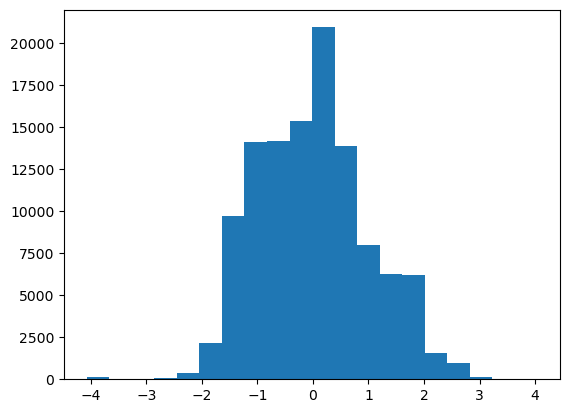

In [17]:
plt.hist(features_scaled_df["tempo"], bins=20)
plt.show()

In [ ]:
final_df.to_csv('../app/data/metadata.csv')